Dataset path: /kaggle/input/datasets/shreyansdeshpande/cnnfinale/FINALCNNDATA_FINAL
Dataset exists: True
Statistics path: /kaggle/working/channel_stats.npz
Training patches: 2549
Merged Validation patches: 1068
Existing channel statistics loaded.

Image batch shape: torch.Size([16, 11, 250, 250])
Label batch shape: torch.Size([16])

Using device: cuda
Epoch 1/15 | Train Loss: 0.9271 | Train Acc: 63.83% | Val Loss: 0.8987 | Val Acc: 69.94%
Epoch 2/15 | Train Loss: 0.9095 | Train Acc: 64.46% | Val Loss: 0.9275 | Val Acc: 61.80%
Epoch 3/15 | Train Loss: 0.9120 | Train Acc: 64.30% | Val Loss: 0.8946 | Val Acc: 64.89%
Epoch 4/15 | Train Loss: 0.9046 | Train Acc: 64.42% | Val Loss: 0.8811 | Val Acc: 64.33%
Epoch 5/15 | Train Loss: 0.8977 | Train Acc: 64.81% | Val Loss: 0.8753 | Val Acc: 62.92%
Epoch 6/15 | Train Loss: 0.8957 | Train Acc: 64.81% | Val Loss: 0.8595 | Val Acc: 69.66%
Epoch 7/15 | Train Loss: 0.8984 | Train Acc: 65.01% | Val Loss: 0.9046 | Val Acc: 63.48%
Epoch 8/15 | Train Loss

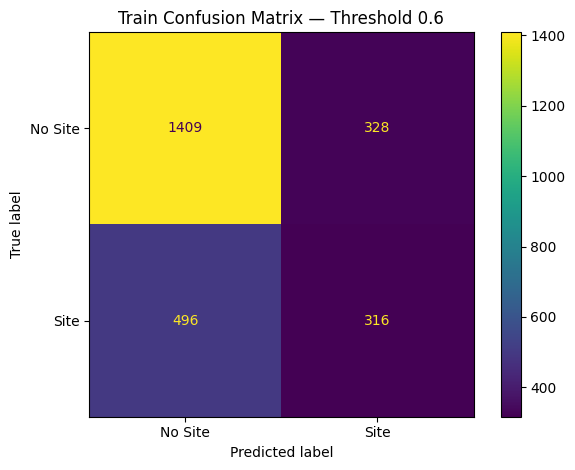

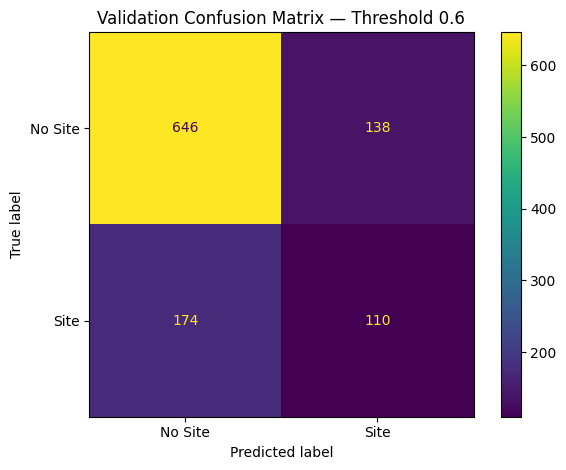

Model weights saved to /kaggle/working/model_20260814_110103.pth

Run logged to /kaggle/working/experiment_log.csv


In [4]:
# 1. IMPORT LIBRARIES
from pathlib import Path
import csv
import inspect
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 2. KAGGLE DATASET PATHS
datasetPath = Path(
    "/kaggle/input/datasets/shreyansdeshpande/"
    "cnnfinale/FINALCNNDATA_FINAL"
)
statsPath = Path("/kaggle/working/channel_stats.npz")
resultsLogPath = Path("/kaggle/working/experiment_log.csv")

if not datasetPath.exists():
    raise FileNotFoundError(f"Dataset folder not found:\n{datasetPath}")

print("Dataset path:", datasetPath)
print("Dataset exists:", datasetPath.exists())
print("Statistics path:", statsPath)


# 3. COLLECT TRAIN AND VALIDATION RECORDS
classMapping = {"no_site": 0, "site": 1}

def collectRecords(splitName):
    records = []
    for className, label in classMapping.items():
        folderPath = datasetPath / splitName / className
        if not folderPath.exists():
            raise FileNotFoundError(f"Folder not found:\n{folderPath}")

        tifFiles = sorted(
            list(folderPath.glob("*.tif")) + list(folderPath.glob("*.tiff"))
        )
        for filePath in tifFiles:
            records.append((filePath, label))
    return records

trainRecords = collectRecords("train")
# Merge validation and test into a single validation set to increase validation area
validationRecords = collectRecords("validation") + collectRecords("test")

print("Training patches:", len(trainRecords))
print("Merged Validation patches:", len(validationRecords))


# 4. CALCULATE OR LOAD CHANNEL STATISTICS
numChannels = 11

def calculateChannelStats(records):
    channelSum = np.zeros(numChannels, dtype=np.float64)
    channelSquaredSum = np.zeros(numChannels, dtype=np.float64)
    channelPixelCount = np.zeros(numChannels, dtype=np.int64)

    for filePath, label in tqdm(records, desc="Calculating channel statistics"):
        with rasterio.open(filePath) as raster:
            image = raster.read(masked=True).astype(np.float64)

        for channelIndex in range(numChannels):
            validValues = image[channelIndex].compressed()
            validValues = validValues[np.isfinite(validValues)]
            if validValues.size == 0:
                continue
            channelSum[channelIndex] += validValues.sum()
            channelSquaredSum[channelIndex] += np.square(validValues).sum()
            channelPixelCount[channelIndex] += validValues.size

    if np.any(channelPixelCount == 0):
        raise ValueError("At least one channel contains no valid pixels.")

    channelMeans = channelSum / channelPixelCount
    channelVariances = (channelSquaredSum / channelPixelCount) - np.square(channelMeans)
    channelVariances = np.maximum(channelVariances, 1e-12)
    channelStds = np.sqrt(channelVariances)

    return channelMeans.astype(np.float32), channelStds.astype(np.float32)

if statsPath.exists():
    savedStats = np.load(statsPath)
    channelMeans = savedStats["means"]
    channelStds = savedStats["stds"]
    print("Existing channel statistics loaded.")
else:
    channelMeans, channelStds = calculateChannelStats(trainRecords)
    np.savez(statsPath, means=channelMeans, stds=channelStds)
    print("Channel statistics calculated and saved.")


# 5. CREATE THE PYTORCH DATASET
class ArchaeologyDataset(Dataset):
    def __init__(self, records, channelMeans, channelStds, augment=False):
        self.records = records
        self.augment = augment
        self.channelMeans = channelMeans.reshape(numChannels, 1, 1).astype(np.float32)
        self.channelStds = channelStds.reshape(numChannels, 1, 1).astype(np.float32)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        filePath, label = self.records[index]
        with rasterio.open(filePath) as raster:
            image = raster.read(masked=True).astype(np.float32)

        image = image.filled(np.nan)

        for channelIndex in range(numChannels):
            invalidPixels = ~np.isfinite(image[channelIndex])
            image[channelIndex][invalidPixels] = self.channelMeans[channelIndex, 0, 0]

        image = (image - self.channelMeans) / self.channelStds
        
        if self.augment:
              if np.random.rand() < 0.5:
                 image = np.flip(image, axis=2).copy()
              if np.random.rand() < 0.5:
                 image = np.flip(image, axis=1).copy()
              numRotations = np.random.randint(0, 4)
              if numRotations > 0:
                 image = np.rot90(image, k=numRotations, axes=(1, 2)).copy()
                  
        imageTensor = torch.from_numpy(image).float()
        labelTensor = torch.tensor(label, dtype=torch.float32)

        return imageTensor, labelTensor

trainDataset = ArchaeologyDataset(trainRecords, channelMeans, channelStds, augment=True)
validationDataset = ArchaeologyDataset(validationRecords, channelMeans, channelStds, augment=False)


# 6. CREATE THE DATALOADERS
batchSize = 16

trainLoader = DataLoader(
    trainDataset, batch_size=batchSize, shuffle=True, num_workers=2, pin_memory=True
)
validationLoader = DataLoader(
    validationDataset, batch_size=batchSize, shuffle=False, num_workers=2, pin_memory=True
)

images, labels = next(iter(trainLoader))
print("\nImage batch shape:", images.shape)
print("Label batch shape:", labels.shape)


# 7. DEFINE THE CNN MODEL (No MaxPool)
class ArchaeologyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(11, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 5
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.globalPool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.1),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.globalPool(x)
        x = self.classifier(x)
        return x


# 8. DEVICE, LOSS AND OPTIMIZER
runTimestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

model = ArchaeologyCNN().to(device)

# Pos_weight calculation for handling class imbalance
numNoSite = sum(1 for _, label in trainRecords if label == 0)
numSite = sum(1 for _, label in trainRecords if label == 1)
posWeightValue = numNoSite / numSite if numSite > 0 else 1.0

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([posWeightValue], device=device))

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.0001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)


# 9. TRAIN AND VALIDATE THE MODEL (Threshold hardcoded to 0.6)
numEpochs = 15
trainLosses, validationLosses = [], []
trainAccuracies, validationAccuracies = [], []
EVAL_THRESHOLD = 0.6

for epoch in range(numEpochs):
    # --- TRAINING ---
    model.train()
    totalTrainLoss, correctTrain, totalTrain = 0.0, 0, 0

    for images, labels in trainLoader:
        images = images.to(device)
        labels = labels.to(device).float().view(-1, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        currentBatchSize = images.size(0)
        totalTrainLoss += loss.item() * currentBatchSize

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= EVAL_THRESHOLD).long()
        correctTrain += (predictions == labels.long()).sum().item()
        totalTrain += currentBatchSize

    trainLoss = totalTrainLoss / totalTrain
    trainAccuracy = correctTrain / totalTrain

    # --- VALIDATION ---
    model.eval()
    totalValidationLoss, correctValidation, totalValidation = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in validationLoader:
            images = images.to(device)
            labels = labels.to(device).float().view(-1, 1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            currentBatchSize = images.size(0)
            totalValidationLoss += loss.item() * currentBatchSize

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= EVAL_THRESHOLD).long()
            correctValidation += (predictions == labels.long()).sum().item()
            totalValidation += currentBatchSize

    validationLoss = totalValidationLoss / totalValidation
    validationAccuracy = correctValidation / totalValidation

    trainLosses.append(trainLoss)
    validationLosses.append(validationLoss)
    trainAccuracies.append(trainAccuracy)
    validationAccuracies.append(validationAccuracy)

    scheduler.step(validationLoss)
    print(
        f"Epoch {epoch + 1}/{numEpochs} | "
        f"Train Loss: {trainLoss:.4f} | Train Acc: {trainAccuracy * 100:.2f}% | "
        f"Val Loss: {validationLoss:.4f} | Val Acc: {validationAccuracy * 100:.2f}%"
    )

# =========================================================
# MODEL EVALUATION ON TRAIN & VAL (THRESHOLD = 0.6)
# =========================================================

def collectPredictions(model, dataLoader, device):
    model.eval()
    allLabels = []
    allProbabilities = []
    with torch.no_grad():
        for images, labels in dataLoader:
            images = images.to(device)
            outputs = model(images)
            probabilities = torch.sigmoid(outputs).squeeze(1)
            
            allLabels.extend(labels.cpu().numpy().astype(int))
            allProbabilities.extend(probabilities.cpu().numpy())

    return np.array(allLabels), np.array(allProbabilities)


trainLabels, trainProbabilities = collectPredictions(model, trainLoader, device)
validationLabels, validationProbabilities = collectPredictions(model, validationLoader, device)


def calculateMetrics(labels, probabilities, threshold=0.6):
    predictions = (probabilities >= threshold).astype(int)
    
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, zero_division=0)
    recall = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)
    
    rocAuc = roc_auc_score(labels, probabilities) if len(np.unique(labels)) == 2 else np.nan
    matrix = confusion_matrix(labels, predictions, labels=[0, 1])

    return {
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": rocAuc,
        "predictions": predictions,
        "confusion_matrix": matrix
    }

trainResults = calculateMetrics(trainLabels, trainProbabilities, threshold=EVAL_THRESHOLD)
validationResults = calculateMetrics(validationLabels, validationProbabilities, threshold=EVAL_THRESHOLD)

def printResults(resultName, results):
    print(f"\n{resultName}\n" + "=" * 50)
    print(f"Threshold : {results['threshold']:.2f}")
    print(f"Accuracy  : {results['accuracy']:.4f} ({results['accuracy'] * 100:.2f}%)")
    print(f"Precision : {results['precision']:.4f}")
    print(f"Recall    : {results['recall']:.4f}")
    print(f"F1 Score  : {results['f1']:.4f}")
    print(f"ROC-AUC   : {results['roc_auc']:.4f}")
    print("\nConfusion Matrix:\n", results["confusion_matrix"])

printResults(f"TRAINING SET RESULTS AT THRESHOLD {EVAL_THRESHOLD}", trainResults)
printResults(f"VALIDATION SET RESULTS AT THRESHOLD {EVAL_THRESHOLD}", validationResults)


# =========================================================
# CONFUSION MATRICES PLOTS
# =========================================================

def plotConfusionMatrix(results, title, savePath):
    display = ConfusionMatrixDisplay(
        confusion_matrix=results["confusion_matrix"], display_labels=["No Site", "Site"]
    )
    display.plot(values_format="d")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(savePath, dpi=300, bbox_inches="tight")
    plt.show()

plotConfusionMatrix(
    trainResults, 
    f"Train Confusion Matrix — Threshold {EVAL_THRESHOLD}", 
    "/kaggle/working/confusion_matrix_train.png"
)

plotConfusionMatrix(
    validationResults, 
    f"Validation Confusion Matrix — Threshold {EVAL_THRESHOLD}", 
    "/kaggle/working/confusion_matrix_val.png"
)


# =========================================================
# SAVE MODEL & LOG RESULTS
# =========================================================
modelSavePath = f"/kaggle/working/model_{runTimestamp}.pth"
torch.save(model.state_dict(), modelSavePath)
print(f"Model weights saved to {modelSavePath}")

modelCodePath = f"/kaggle/working/model_code_{runTimestamp}.py"
try:
    architectureSource = inspect.getsource(ArchaeologyCNN)
except OSError:
    architectureSource = "# Source unavailable: ArchaeologyCNN was defined interactively."
    
with open(modelCodePath, "w") as f:
    f.write(architectureSource)

runRecord = {
    "timestamp": runTimestamp,
    "numChannels": numChannels,
    "batchSize": batchSize,
    "numEpochs": numEpochs,
    "learningRate": optimizer.param_groups[0]["lr"],
    "weightDecay": optimizer.param_groups[0]["weight_decay"],
    "posWeight": posWeightValue,
    "finalTrainLoss": trainLosses[-1],
    "finalValLoss": validationLosses[-1],
    "finalTrainAcc": trainAccuracies[-1],
    "finalValAcc": validationAccuracies[-1],
    "evalThreshold": EVAL_THRESHOLD,
    "val_accuracy": validationResults["accuracy"],
    "val_precision": validationResults["precision"],
    "val_recall": validationResults["recall"],
    "val_f1": validationResults["f1"],
    "val_rocauc": validationResults["roc_auc"],
    "modelSavePath": modelSavePath,
}

fileExists = resultsLogPath.exists()
with open(resultsLogPath, mode="a", newline="") as csvFile:
    writer = csv.DictWriter(csvFile, fieldnames=runRecord.keys())
    if not fileExists:
        writer.writeheader()
    writer.writerow(runRecord)

print(f"\nRun logged to {resultsLogPath}")

In [4]:
import os

statsPath = "/kaggle/working/channel_stats.npz"

if os.path.exists(statsPath):
    os.remove(statsPath)
    print("Deleted stale channel_stats.npz")

Deleted stale channel_stats.npz


In [16]:
import os

print("Contents of /kaggle/input:")
print(os.listdir("/kaggle/input/datasets/shreyansdeshpande/cnnfinale/FINALCNNDATA_FINAL"))

# Verify full path dynamically
input_base = "/kaggle/input"
for item in os.listdir(input_base):
    if "cnnfinale" in item.lower():
        full_path = os.path.join(input_base, item, "FINALCNNDATA_FINAL")
        print(f"Found dataset at: {full_path}")
        print("Subfolders:", os.listdir(full_path))

Contents of /kaggle/input:
['_split_reports', 'validation', 'test', 'train']
